In [1]:
# BASIC STATISTICS, DESCRIPTIVE ANALYTICS & DATA PREPROCESSING

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load Dataset
# Replace file path with your dataset path if running locally
df = pd.read_csv(r"C:\Users\admin\Downloads\Excelr Assignment\Basic stats - 1\Basic stats - 1\sales_data_with_discounts.csv")

# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [3]:
# 2. Identify Numerical & Categorical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("\nNumerical Columns:", list(numerical_cols))
print("Categorical Columns:", list(categorical_cols))



Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


In [4]:
# 3. Descriptive Analytics for Numerical Columns
print("\n--- Basic Statistics for Numerical Columns ---")
for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] if not df[col].mode().empty else None
    std_val = df[col].std()
    print(f"\nColumn: {col}")
    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Mode: {mode_val}")
    print(f"Standard Deviation: {std_val:.2f}")


--- Basic Statistics for Numerical Columns ---

Column: Volume
Mean: 5.07
Median: 4.00
Mode: 3
Standard Deviation: 4.23

Column: Avg Price
Mean: 10453.43
Median: 1450.00
Mode: 400
Standard Deviation: 18079.90

Column: Total Sales Value
Mean: 33812.84
Median: 5700.00
Mode: 24300
Standard Deviation: 50535.07

Column: Discount Rate (%)
Mean: 15.16
Median: 16.58
Mode: 5.007822189204133
Standard Deviation: 4.22

Column: Discount Amount
Mean: 3346.50
Median: 988.93
Mode: 69.17794228822787
Standard Deviation: 4509.90

Column: Net Sales Value
Mean: 30466.34
Median: 4677.79
Mode: 326.97480055470817
Standard Deviation: 46358.66



--- Histograms for Numerical Columns ---


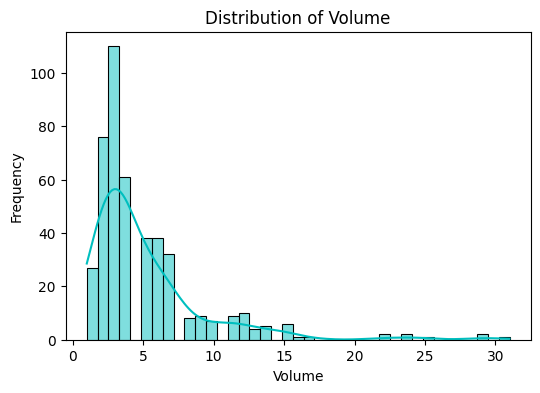

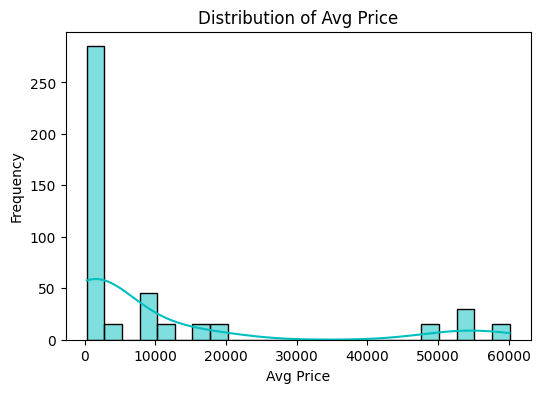

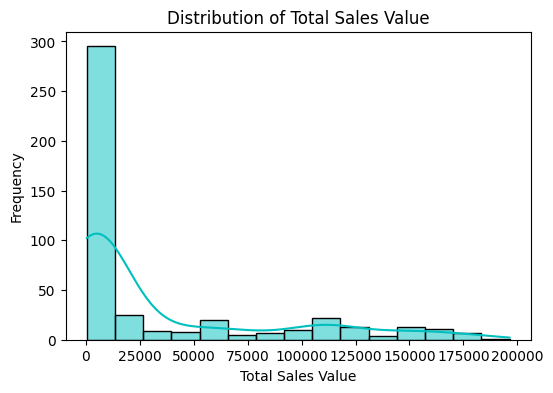

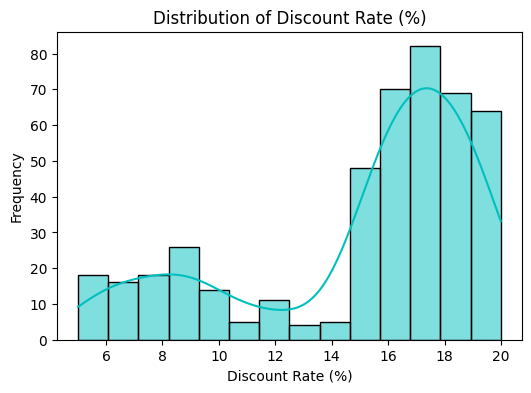

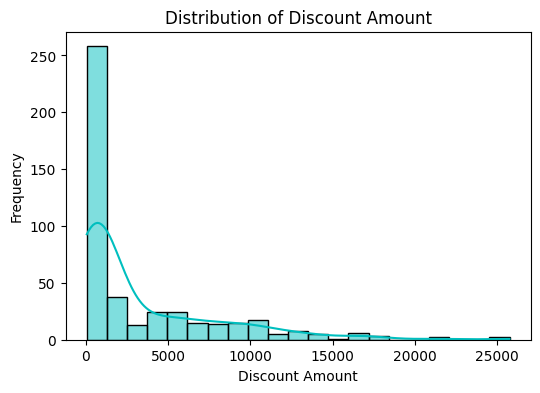

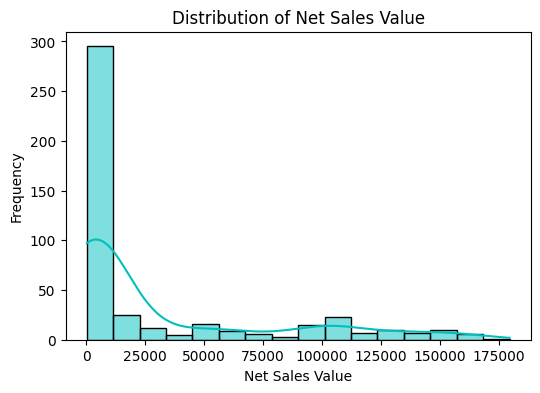

In [5]:
# 4. Data Visualization - Histograms
print("\n--- Histograms for Numerical Columns ---")
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='c')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


--- Boxplots for Numerical Columns ---


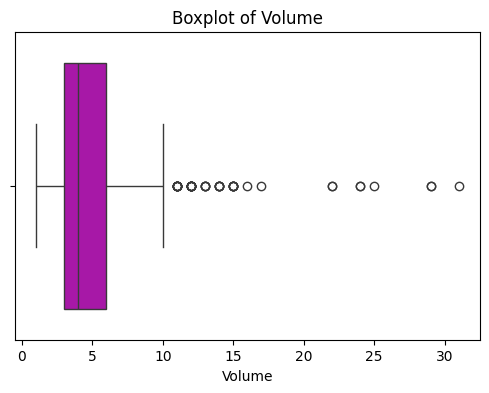

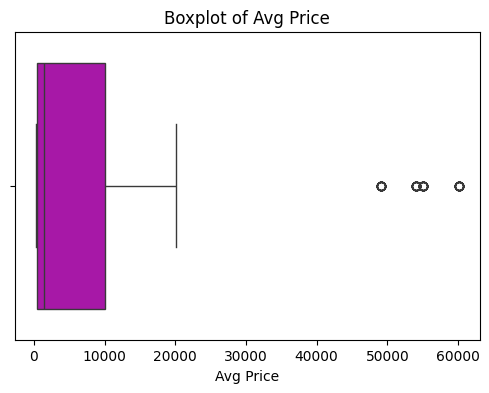

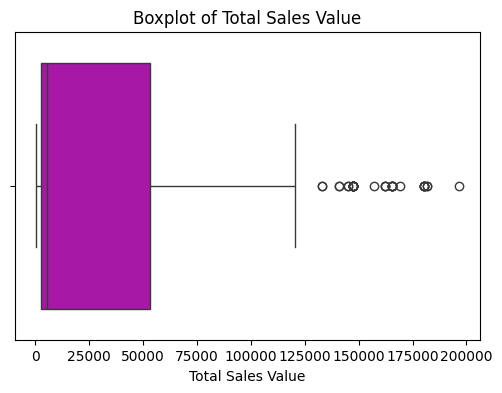

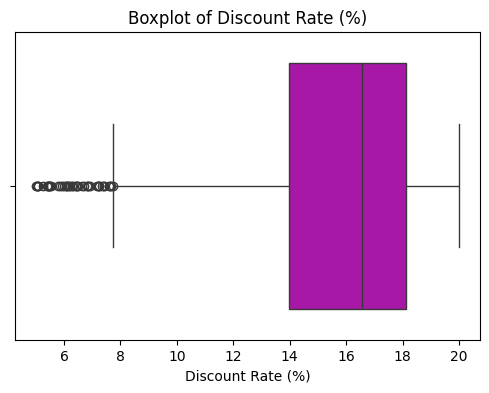

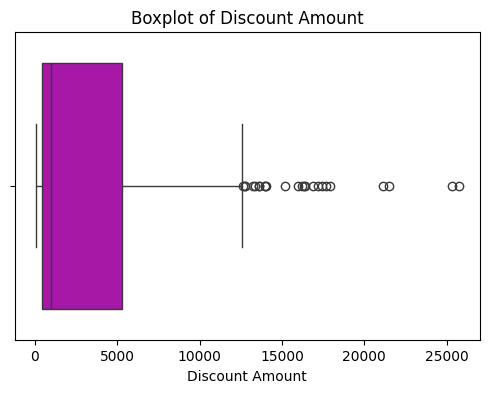

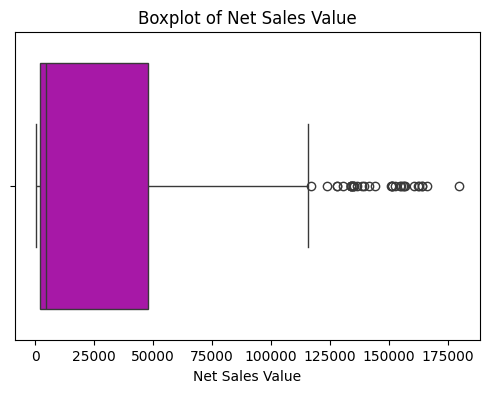

In [6]:
# 5. Data Visualization - Boxplots
print("\n--- Boxplots for Numerical Columns ---")
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='m')
    plt.title(f"Boxplot of {col}")
    plt.show()


--- Bar Charts for Categorical Columns ---


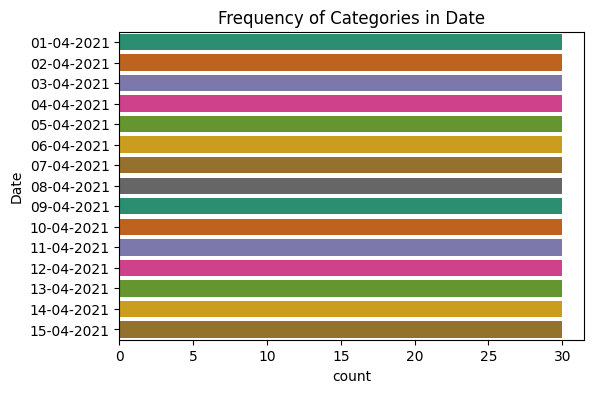

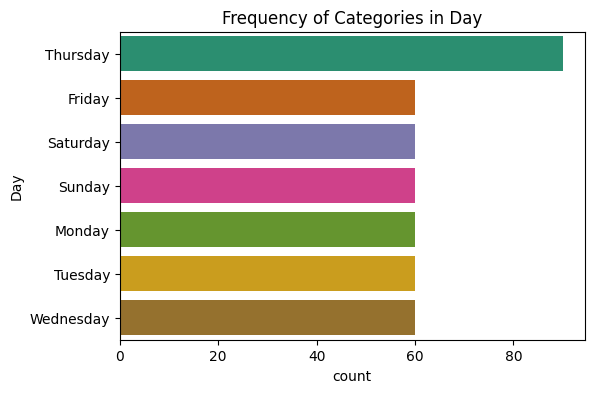

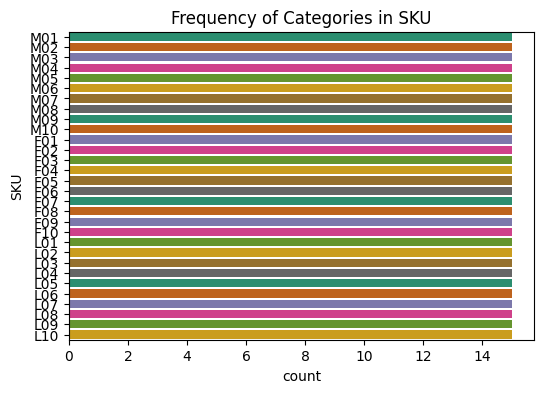

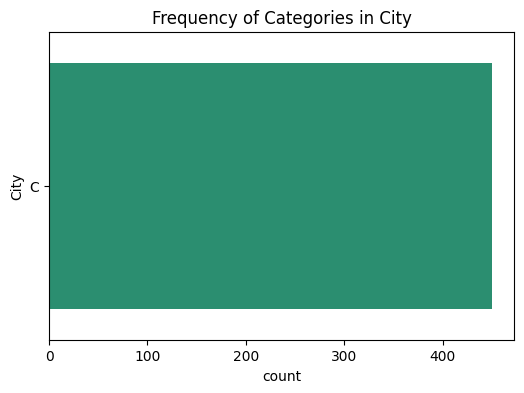

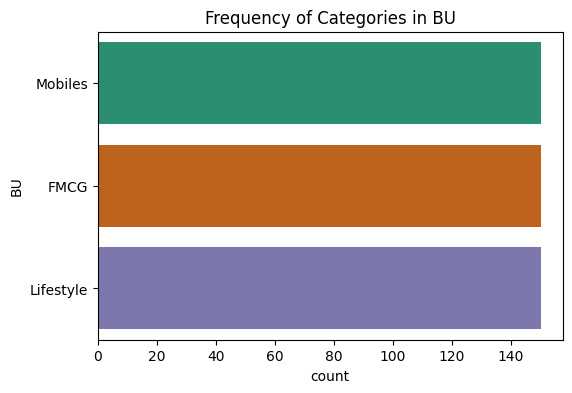

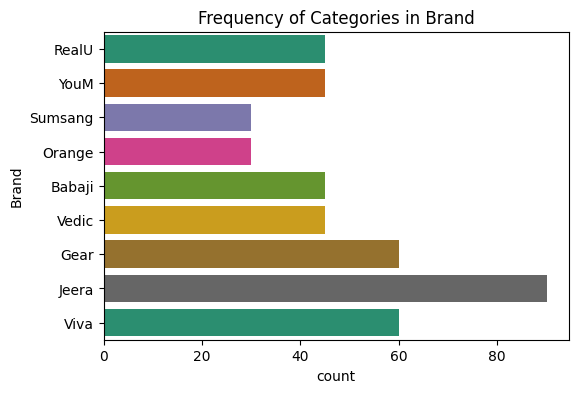

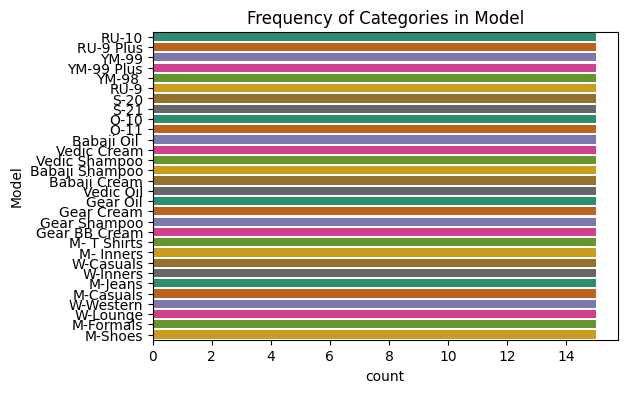

In [7]:
# 6. Bar Chart Analysis for Categorical Columns
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")  # This will hide all warnings
print("\n--- Bar Charts for Categorical Columns ---")
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=df[col], palette='Dark2')
    plt.title(f"Frequency of Categories in {col}")
    plt.show()


--- Standardization of Numerical Columns ---


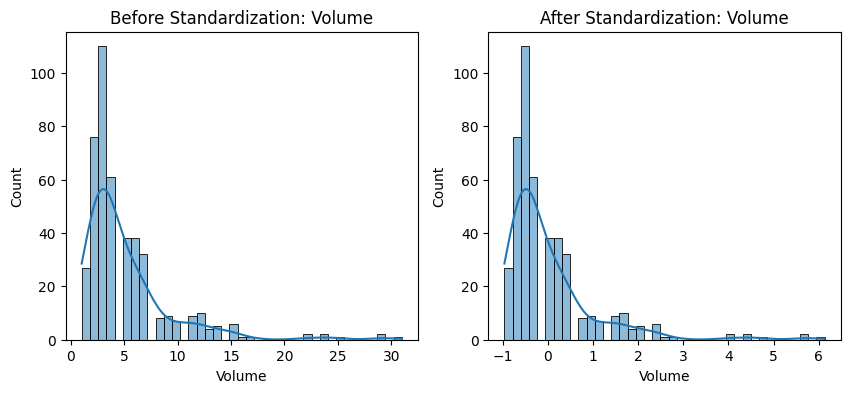

In [8]:
# 7. Standardization (Z-score Normalization)
# ------------------------------------------------------------
# Formula: z = (x - mean) / std
print("\n--- Standardization of Numerical Columns ---")
df_standardized = df.copy()
for col in numerical_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df_standardized[col] = (df[col] - mean_val) / std_val

# Show before & after comparison for first numerical column
first_num_col = numerical_cols[0]
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df[first_num_col], kde=True)
plt.title(f"Before Standardization: {first_num_col}")

plt.subplot(1,2,2)
sns.histplot(df_standardized[first_num_col], kde=True)
plt.title(f"After Standardization: {first_num_col}")

plt.show()

In [9]:
# 8. Conversion of Categorical Data into Dummy Variables
# ------------------------------------------------------------
print("\n--- One-Hot Encoding Categorical Columns ---")
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display first few rows of transformed dataset
display(df_encoded.head())


--- One-Hot Encoding Categorical Columns ---


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
